In [30]:
import pandas as pd
import numpy as np

import yfinance as yf

import matplotlib.pylab as plt

In [2]:
tickers = ["LLY", "NVDA", "MSFT", "KXI"]

start_date = "2018-01-01"
end_date = "2026-02-26"

In [3]:
prices = yf.download(tickers=tickers, start=start_date, end=end_date)["Close"]
prices.head(4)

/home/rigodev/ITESO/06/portafolios/env/lib/python3.12/site-packages/yfinance/scrapers/history.py:201: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  4 of 4 completed


Ticker,KXI,LLY,MSFT,NVDA
Date,,,,
2018-01-02,43.383408,75.026703,78.870361,4.928532
2018-01-03,43.387516,75.434265,79.237434,5.252898
2018-01-04,43.482098,75.770950,79.934814,5.280588
2018-01-05,43.761730,76.701248,80.925865,5.325337


In [24]:
prices_assets = prices.iloc[:, 1:5]
prices_benchmark = prices.iloc[:, :1]

prices_benchmark

Ticker,KXI
Date,
2018-01-02,43.383408
2018-01-03,43.387516
2018-01-04,43.482098
2018-01-05,43.761730
2018-01-08,43.745277
...,...
2026-02-19,72.110001
2026-02-20,72.269997
2026-02-23,72.889999


In [26]:
pd.concat([prices_assets, prices_benchmark], axis = 1)

Ticker,LLY,MSFT,NVDA,KXI
Date,,,,
2018-01-02,75.026703,78.870361,4.928532,43.383408
2018-01-03,75.434265,79.237434,5.252898,43.387516
2018-01-04,75.770950,79.934814,5.280588,43.482098
2018-01-05,76.701248,80.925865,5.325337,43.761730
2018-01-08,76.311409,81.008438,5.488509,43.745277
...,...,...,...,...
2026-02-19,1023.219971,398.459991,187.899994,72.110001
2026-02-20,1009.520020,397.230011,189.820007,72.269997
2026-02-23,1058.560059,384.470001,191.550003,72.889999


In [ ]:
def correlation_over_time(prices: pd.DataFrame, benchmark : pd.DataFrame = None):
    df = pd.concat([prices, benchmark], axis = 1)
    
    returns = df.pct_change().dropna()
    
    particiones = []
    
    n = len(returns["KXI"])
    
    for i in range(30, n+30):
        particion = returns.iloc[:i, :]
        particion_corr = particion.corr()
        
        particiones.append(particion_corr)
    
    return particiones


print(correlation_over_time(prices=prices_assets, benchmark=prices_benchmark)[0])

Ticker       KXI       LLY      MSFT      NVDA
Ticker                                        
KXI     1.000000  0.624507  0.755089  0.662569
LLY     0.624507  1.000000  0.586903  0.588424
MSFT    0.755089  0.586903  1.000000  0.770134
NVDA    0.662569  0.588424  0.770134  1.000000


In [8]:
n = len(prices["KXI"])
n

2048

In [39]:
particiones = []

for i in range(30, len(prices["KXI"])+30):
    particion = prices.iloc[0:i,:]
    corr = particion.corr()
    result = corr["KXI"]
    
    particiones.append(result)
    

result = np.array(particiones).T

result

array([[1.        , 1.        , 1.        , ..., 1.        , 1.        ,
        1.        ],
       [0.85621262, 0.86450553, 0.86884011, ..., 0.85750987, 0.85750987,
        0.85750987],
       [0.56325534, 0.52344004, 0.46674065, ..., 0.9383682 , 0.9383682 ,
        0.9383682 ],
       [0.38787033, 0.31522643, 0.24885226, ..., 0.80798116, 0.80798116,
        0.80798116]], shape=(4, 2048))

In [43]:
np.corrcoef(result[1], result[2])

array([[1.        , 0.70691643],
       [0.70691643, 1.        ]])

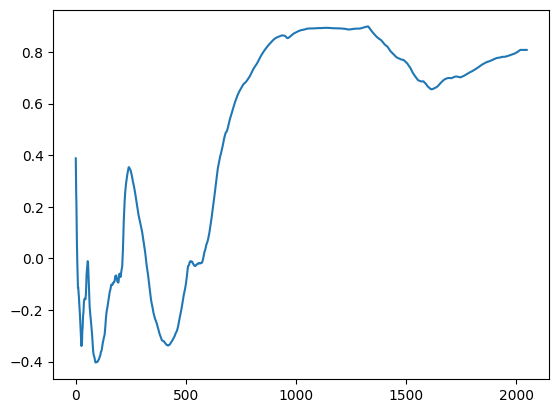

In [38]:
plt.plot(result)

In [ ]:
range(30, n+30)

30